# COVID-19 Open Research Dataset (CORD-19) Analysis

**Analysis Contents:**
1. Data Loading and Initial Exploration
2. Missing Data Analysis
3. Publication Timeline Analysis
4. Text Analysis
5. COVID-19 Keyword Analysis
6. Author Analysis
7. Document Type and Venue Analysis
8. Word Cloud Generation
9. Summary Statistics and Data Quality Report


## Import Libraries and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from collections import Counter
from datetime import datetime
from wordcloud import WordCloud
import re

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## 1. Data Loading and Initial Exploration

Cell này tải file metadata.csv và cung cấp cái nhìn tổng quan về dataset. Dataset chứa thông tin chi tiết về các bài báo nghiên cứu bao gồm: ID duy nhất, tiêu đề, tóm tắt, tác giả, tạp chí, thời gian xuất bản và các thông tin metadata khác.


In [2]:
metadata = pd.read_csv('data/metadata.csv', low_memory=False)

print("DATASET OVERVIEW")
print(f"Total number of papers: {len(metadata):,}")
print(f"Number of columns: {metadata.shape[1]}")
print(f"Memory usage: {metadata.memory_usage().sum() / 1024**2:.2f} MB")

print("\nColumn Information:")
for i, col in enumerate(metadata.columns):
    non_null = metadata[col].notna().sum()
    print(f"{i+1:2d}. {col:<25} | Non-null: {non_null:>8,} ({non_null/len(metadata)*100:5.1f}%)")


DATASET OVERVIEW
Total number of papers: 1,056,660
Number of columns: 19
Memory usage: 153.17 MB

Column Information:
 1. cord_uid                  | Non-null: 1,056,660 (100.0%)
 2. sha                       | Non-null:  373,766 ( 35.4%)
 3. source_x                  | Non-null: 1,056,660 (100.0%)
 4. title                     | Non-null: 1,056,157 (100.0%)
 5. doi                       | Non-null:  656,780 ( 62.2%)
 6. pmcid                     | Non-null:  389,571 ( 36.9%)
 7. pubmed_id                 | Non-null:  498,932 ( 47.2%)
 8. license                   | Non-null: 1,056,660 (100.0%)
 9. abstract                  | Non-null:  821,116 ( 77.7%)
10. publish_time              | Non-null: 1,054,846 ( 99.8%)
11. authors                   | Non-null: 1,032,791 ( 97.7%)
12. journal                   | Non-null:  969,338 ( 91.7%)
13. mag_id                    | Non-null:        0 (  0.0%)
14. who_covidence_id          | Non-null:  482,935 ( 45.7%)
15. arxiv_id                  | Non-

In [3]:
metadata.head(10)


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
5,zjufx4fo,b2897e1277f56641193a6db73825f707eed3e4c9,PMC,Sequence requirements for RNA strand transfer ...,10.1093/emboj/20.24.7220,PMC125340,11742998,green-oa,Nidovirus subgenomic mRNAs contain a leader se...,2001-12-17,"Pasternak, Alexander O.; van den Born, Erwin; ...",The EMBO Journal,NaN,NaN,NaN,document_parses/pdf_json/b2897e1277f56641193a6...,document_parses/pmc_json/PMC125340.xml.json,http://europepmc.org/articles/pmc125340?pdf=re...,NaN
6,5yhe786e,3bb07ea10432f7738413dff9816809cc90f03f99,PMC,Debate: Transfusing to normal haemoglobin leve...,10.1186/cc987,PMC137267,11299062,no-cc,Recent evidence suggests that critically ill p...,2001-03-08,"Alvarez, Gonzalo; Hébert, Paul C; Szick, Sharyn",Crit Care,NaN,NaN,NaN,document_parses/pdf_json/3bb07ea10432f7738413d...,document_parses/pmc_json/PMC137267.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
7,8zchiykl,5806726a24dc91de3954001effbdffd7a82d54e2,PMC,The 21st International Symposium on Intensive ...,10.1186/cc1013,PMC137274,11353930,no-cc,The 21st International Symposium on Intensive ...,2001-05-02,"Ball, Jonathan; Venn, Richard",Crit Care,NaN,NaN,NaN,document_parses/pdf_json/5806726a24dc91de39540...,document_parses/pmc_json/PMC137274.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
8,8qnrcgnk,faaf1022ccfe93b032c5608097a53543ba24aedb,PMC,Heme oxygenase-1 and carbon monoxide in pulmon...,10.1186/1465-9921-4-7,PMC193681,12964953,no-cc,"Heme oxygenase-1 (HO-1), an inducible stress p...",2003-08-07,"Slebos, Dirk-Jan; Ryter, Stefan W; Choi, Augus...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/faaf1022ccfe93b032c56...,document_parses/pmc_json/PMC193681.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
9,jg13scgo,5b44feca5d6ffaaeb6

## 2. Missing Data Analysis

Phần này phân tích các giá trị thiếu (missing values) trong dataset. Biểu đồ cột hiển thị số lượng và tỷ lệ phần trăm dữ liệu thiếu cho từng cột. Heatmap trực quan hóa pattern của dữ liệu thiếu xuyên suốt dataset.

**Ý nghĩa:** Hiểu rõ mức độ thiếu dữ liệu giúp quyết định chiến lược xử lý (loại bỏ, điền giá trị, hoặc giữ nguyên) cho từng trường thông tin.


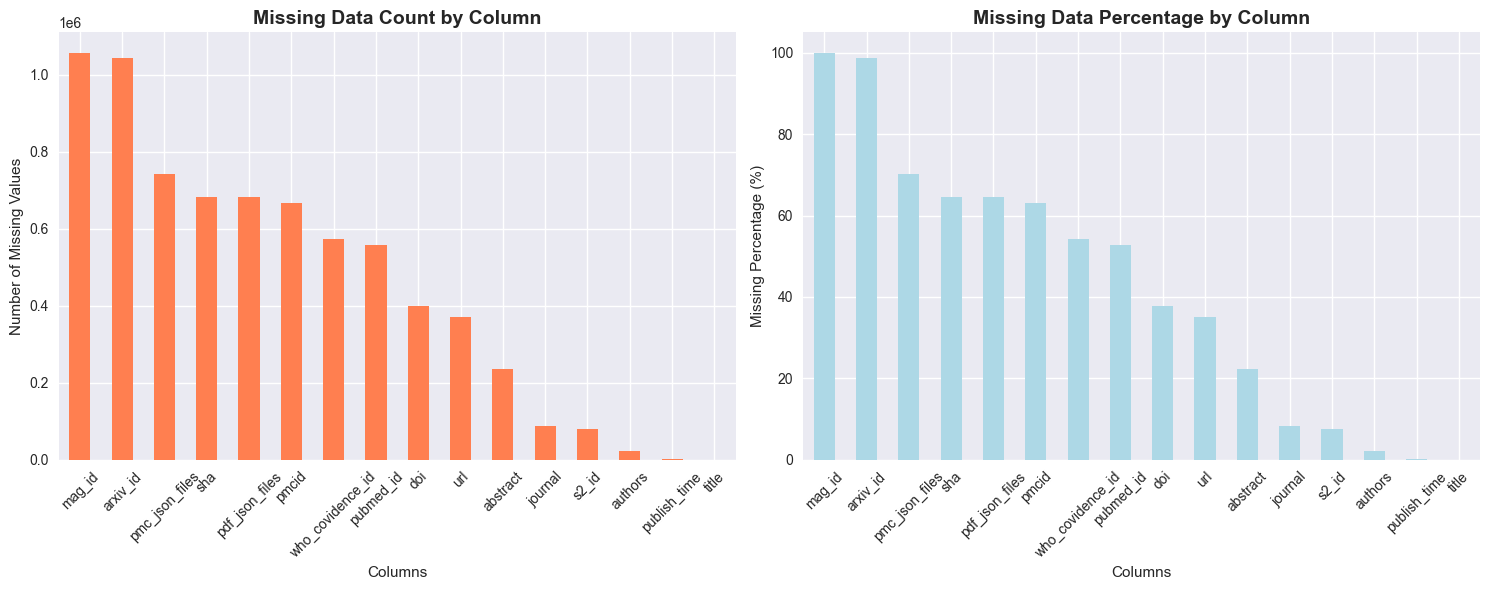

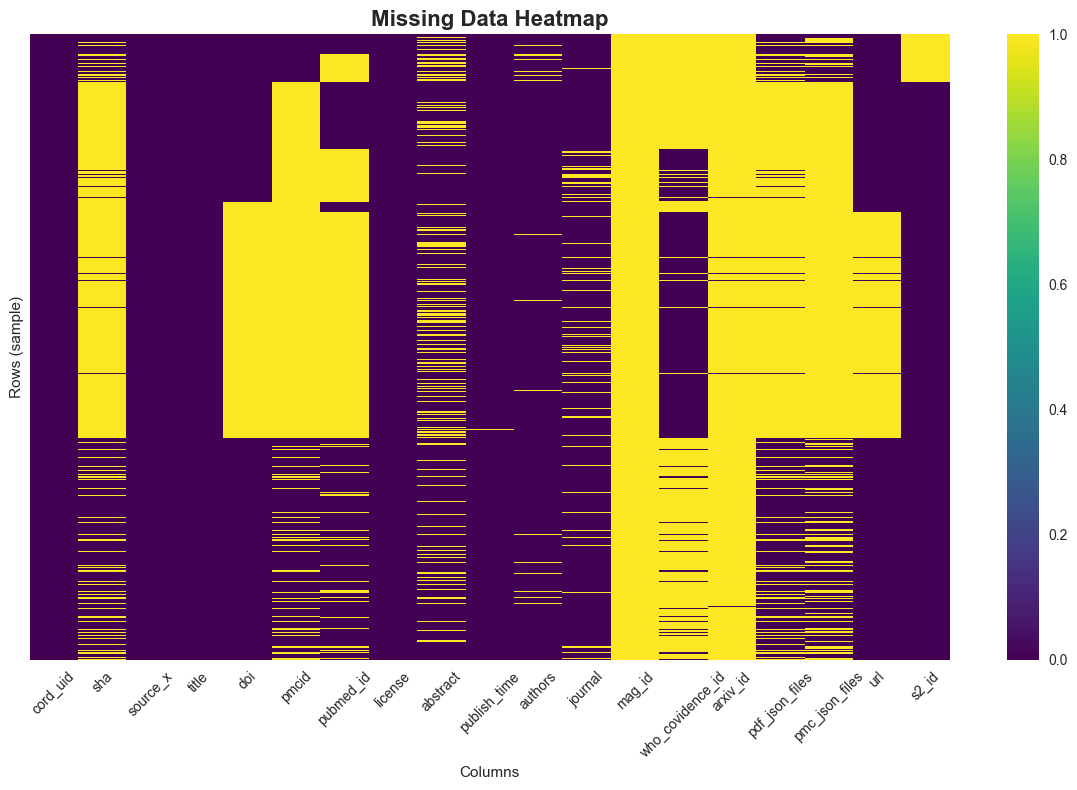

In [4]:
missing_data = metadata.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(metadata)) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

missing_data[missing_data > 0].plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Missing Data Count by Column', fontsize=14, fontweight='bold')
ax1.set_xlabel('Columns')
ax1.set_ylabel('Number of Missing Values')
ax1.tick_params(axis='x', rotation=45)

missing_percent[missing_percent > 0].plot(kind='bar', ax=ax2, color='lightblue')
ax2.set_title('Missing Data Percentage by Column', fontsize=14, fontweight='bold')
ax2.set_xlabel('Columns')
ax2.set_ylabel('Missing Percentage (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(metadata.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Rows (sample)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Kết quả quan sát:**
- `mag_id` thiếu 100% (không hữu ích)
- `arxiv_id` thiếu ~98.7% (chủ yếu là các bài không phải preprint)
- `pmc_json_files` và `pdf_json_files` thiếu ~65-70% (nhiều bài báo không có full text)
- `abstract` thiếu ~22% (quan trọng cho semantic search - cần lọc)
- Các trường core như `cord_uid`, `source_x`, `license`, `title` có dữ liệu đầy đủ


## 3. Publication Timeline Analysis

Phần này phân tích xu hướng xuất bản theo thời gian, bao gồm:
- **Số bài báo theo năm:** Biểu đồ đường thể hiện sự gia tăng đột biến từ năm 2020 (đại dịch COVID-19 bùng phát)
- **Số bài báo theo tháng (2020-2022):** Phân tích chi tiết trong giai đoạn đại dịch
- **Top 15 tạp chí:** Các tạp chí xuất bản nhiều bài nhất
- **Phân bố theo nguồn:** Phân tích nguồn gốc của các bài báo (WHO, Medline, PMC, bioRxiv, etc.)


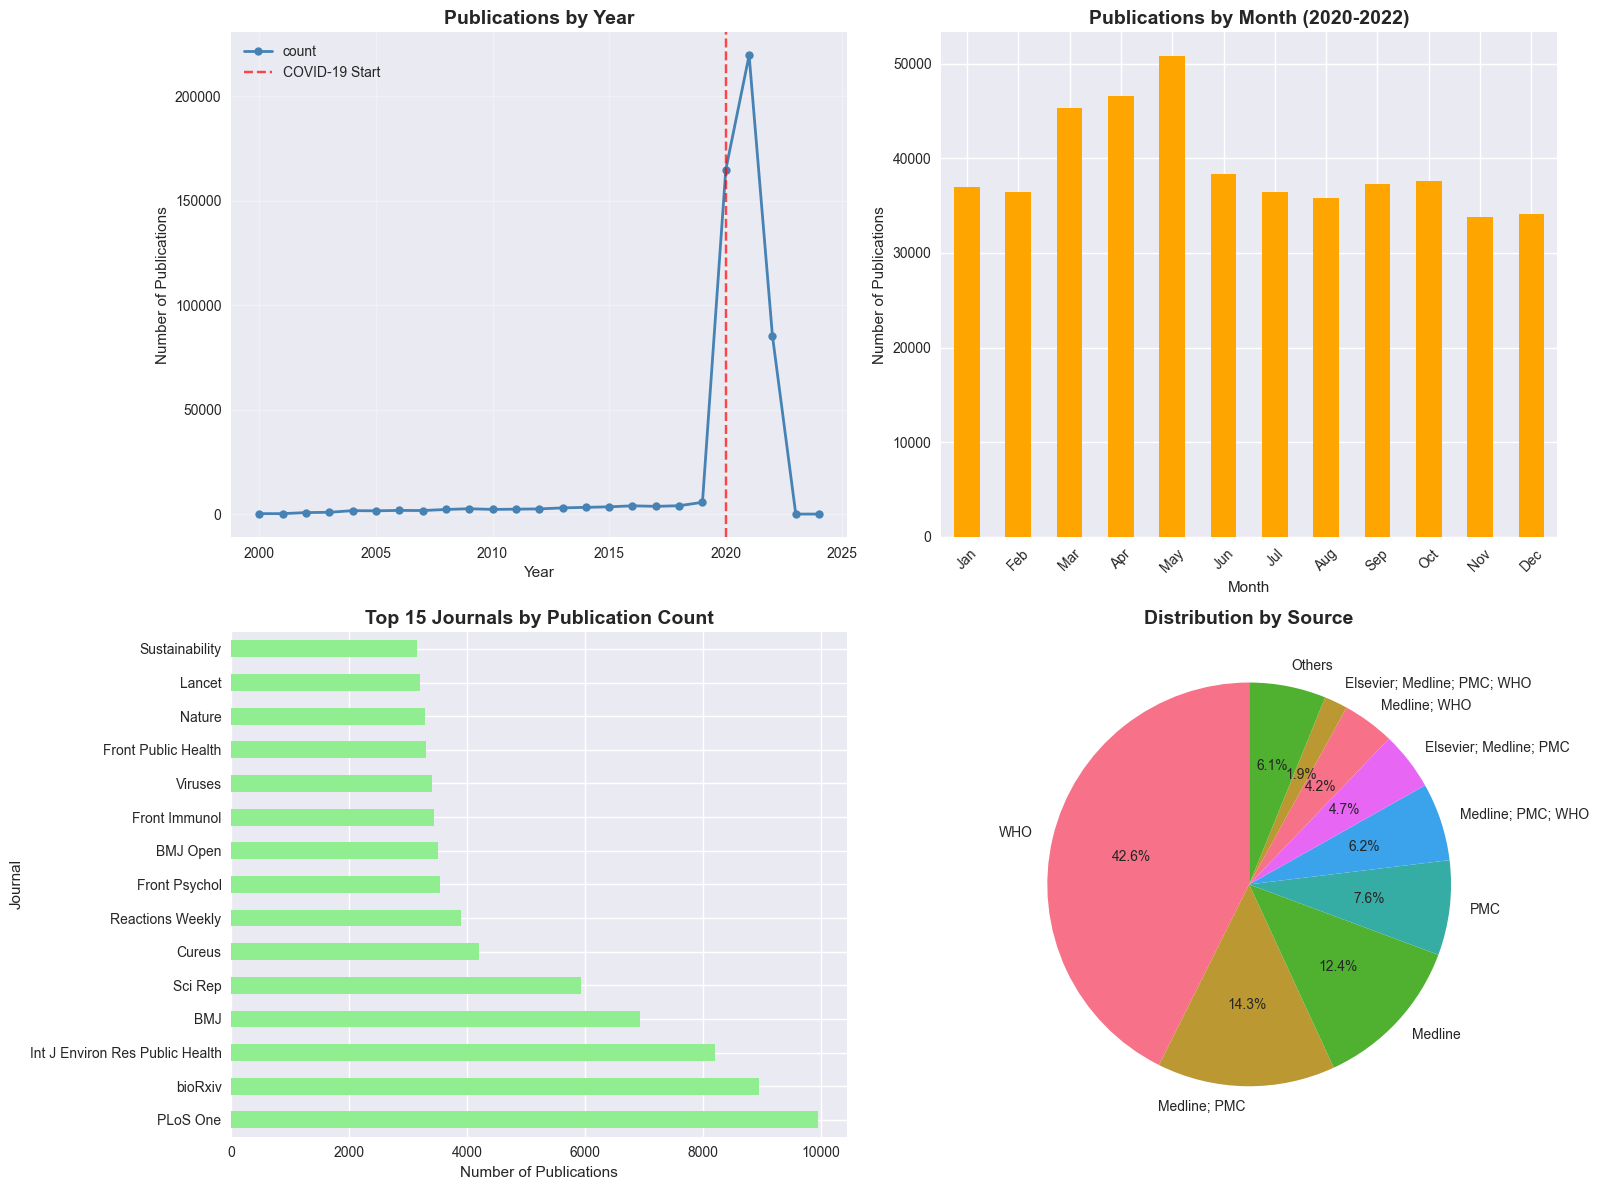

In [5]:
metadata['publish_time'] = pd.to_datetime(metadata['publish_time'], errors='coerce')
metadata['publish_year'] = metadata['publish_time'].dt.year
metadata['publish_month'] = metadata['publish_time'].dt.month

valid_years = metadata[(metadata['publish_year'] >= 2000) & (metadata['publish_year'] <= 2024)]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

yearly_counts = valid_years['publish_year'].value_counts().sort_index()
yearly_counts.plot(kind='line', marker='o', ax=ax1, linewidth=2, markersize=6, color='steelblue')
ax1.set_title('Publications by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Publications')
ax1.grid(True, alpha=0.3)

if 2020 in yearly_counts.index:
    ax1.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID-19 Start')
    ax1.legend()

covid_period = valid_years[valid_years['publish_year'].isin([2020, 2021, 2022])]
if not covid_period.empty:
    valid_months = covid_period['publish_month'].dropna()
    monthly_counts = valid_months.value_counts().sort_index()
    
    if not monthly_counts.empty:
        monthly_counts.plot(kind='bar', ax=ax2, color='orange')
        ax2.set_title('Publications by Month (2020-2022)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Month')
        ax2.set_ylabel('Number of Publications')
        
        month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        valid_indices = [int(i) for i in monthly_counts.index if not pd.isna(i) and 1 <= i <= 12]
        if valid_indices:
            ax2.set_xticklabels([month_labels[i-1] for i in valid_indices], rotation=45)

top_journals = metadata['journal'].value_counts().head(15)
top_journals.plot(kind='barh', ax=ax3, color='lightgreen')
ax3.set_title('Top 15 Journals by Publication Count', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Publications')
ax3.set_ylabel('Journal')

source_counts = metadata['source_x'].value_counts()
top_sources = source_counts.head(8)
others_count = source_counts[8:].sum()
if others_count > 0:
    top_sources = pd.concat([top_sources, pd.Series({'Others': others_count})])

top_sources.plot(kind='pie', ax=ax4, autopct='%1.1f%%', startangle=90)
ax4.set_title('Distribution by Source', fontsize=14, fontweight='bold')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()


**Phát hiện chính:**
- Có sự gia tăng đột biến số lượng bài báo từ 2018-2022, với đỉnh điểm vào năm 2020-2021
- Đường kẻ đỏ đánh dấu năm 2020 cho thấy phản ứng nghiên cứu mạnh mẽ đối với đại dịch
- Các tạp chí hàng đầu bao gồm PLoS One, Int J Environ Res Public Health
- Dữ liệu được tổng hợp từ nhiều nguồn uy tín (WHO, Medline, PMC, bioRxiv)


## 4. Text Analysis

Phân tích độ dài và đặc điểm của tiêu đề và tóm tắt:
- **Phân bố độ dài tiêu đề:** Histogram hiển thị phân bố độ dài tiêu đề (trung bình ~100 ký tự)
- **Phân bố độ dài tóm tắt:** Histogram độ dài abstract (trung bình ~1400 ký tự)
- **Scatter plot:** Mối quan hệ giữa độ dài tiêu đề và tóm tắt
- **Box plot theo năm:** Phân bố độ dài abstract qua các năm gần đây


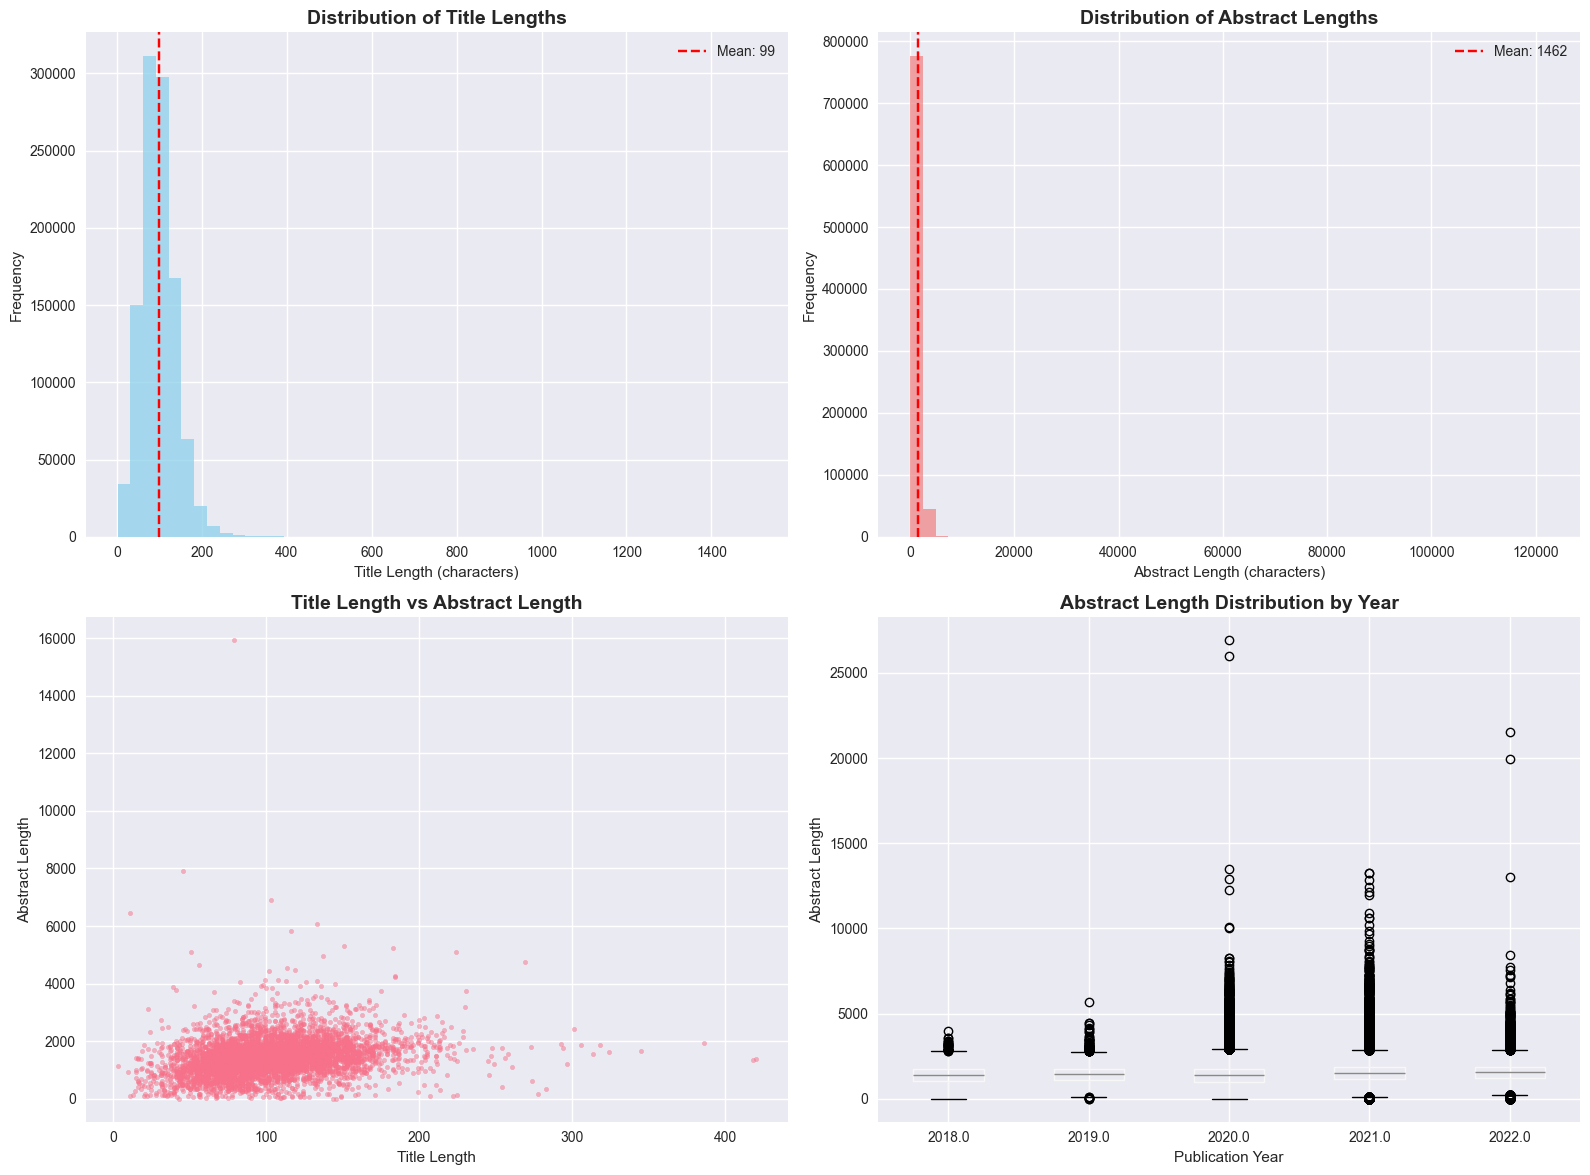

In [6]:
metadata['title_length'] = metadata['title'].astype(str).str.len()
metadata['abstract_length'] = metadata['abstract'].astype(str).str.len()

valid_abstracts = metadata[metadata['abstract'].notna() & (metadata['abstract'] != 'nan')]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

metadata['title_length'].hist(bins=50, ax=ax1, alpha=0.7, color='skyblue')
ax1.set_title('Distribution of Title Lengths', fontsize=14, fontweight='bold')
ax1.set_xlabel('Title Length (characters)')
ax1.set_ylabel('Frequency')
ax1.axvline(metadata['title_length'].mean(), color='red', linestyle='--', 
           label=f'Mean: {metadata["title_length"].mean():.0f}')
ax1.legend()

valid_abstracts['abstract_length'].hist(bins=50, ax=ax2, alpha=0.7, color='lightcoral')
ax2.set_title('Distribution of Abstract Lengths', fontsize=14, fontweight='bold')
ax2.set_xlabel('Abstract Length (characters)')
ax2.set_ylabel('Frequency')
ax2.axvline(valid_abstracts['abstract_length'].mean(), color='red', linestyle='--',
           label=f'Mean: {valid_abstracts["abstract_length"].mean():.0f}')
ax2.legend()

sample_data = valid_abstracts.sample(n=min(5000, len(valid_abstracts)))
ax3.scatter(sample_data['title_length'], sample_data['abstract_length'], 
           alpha=0.5, s=10)
ax3.set_title('Title Length vs Abstract Length', fontsize=14, fontweight='bold')
ax3.set_xlabel('Title Length')
ax3.set_ylabel('Abstract Length')

recent_years = valid_abstracts[valid_abstracts['publish_year'].isin([2018, 2019, 2020, 2021, 2022])]
if not recent_years.empty:
    recent_years.boxplot(column='abstract_length', by='publish_year', ax=ax4)
    ax4.set_title('Abstract Length Distribution by Year', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Publication Year')
    ax4.set_ylabel('Abstract Length')
    plt.suptitle('')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Độ dài tiêu đề trung bình ~100 ký tự (phù hợp cho hiển thị kết quả tìm kiếm)
- Độ dài tóm tắt trung bình ~1400 ký tự (đủ context cho semantic embedding)
- Không có tương quan mạnh giữa độ dài tiêu đề và tóm tắt
- Độ dài tóm tắt tương đối ổn định qua các năm


## 5. COVID-19 Keyword Analysis

Phân tích sự xuất hiện của các từ khóa liên quan đến COVID-19 trong dataset:
- **Tỷ lệ bài báo liên quan COVID:** Pie chart phân loại bài COVID vs Non-COVID
- **Bài báo COVID theo năm:** Xu hướng tăng đột biến từ 2020
- **Từ khóa phổ biến nhất:** Top từ khóa COVID xuất hiện trong tiêu đề
- **Tỷ lệ % theo năm:** Phần trăm bài báo COVID trong tổng số bài mỗi năm


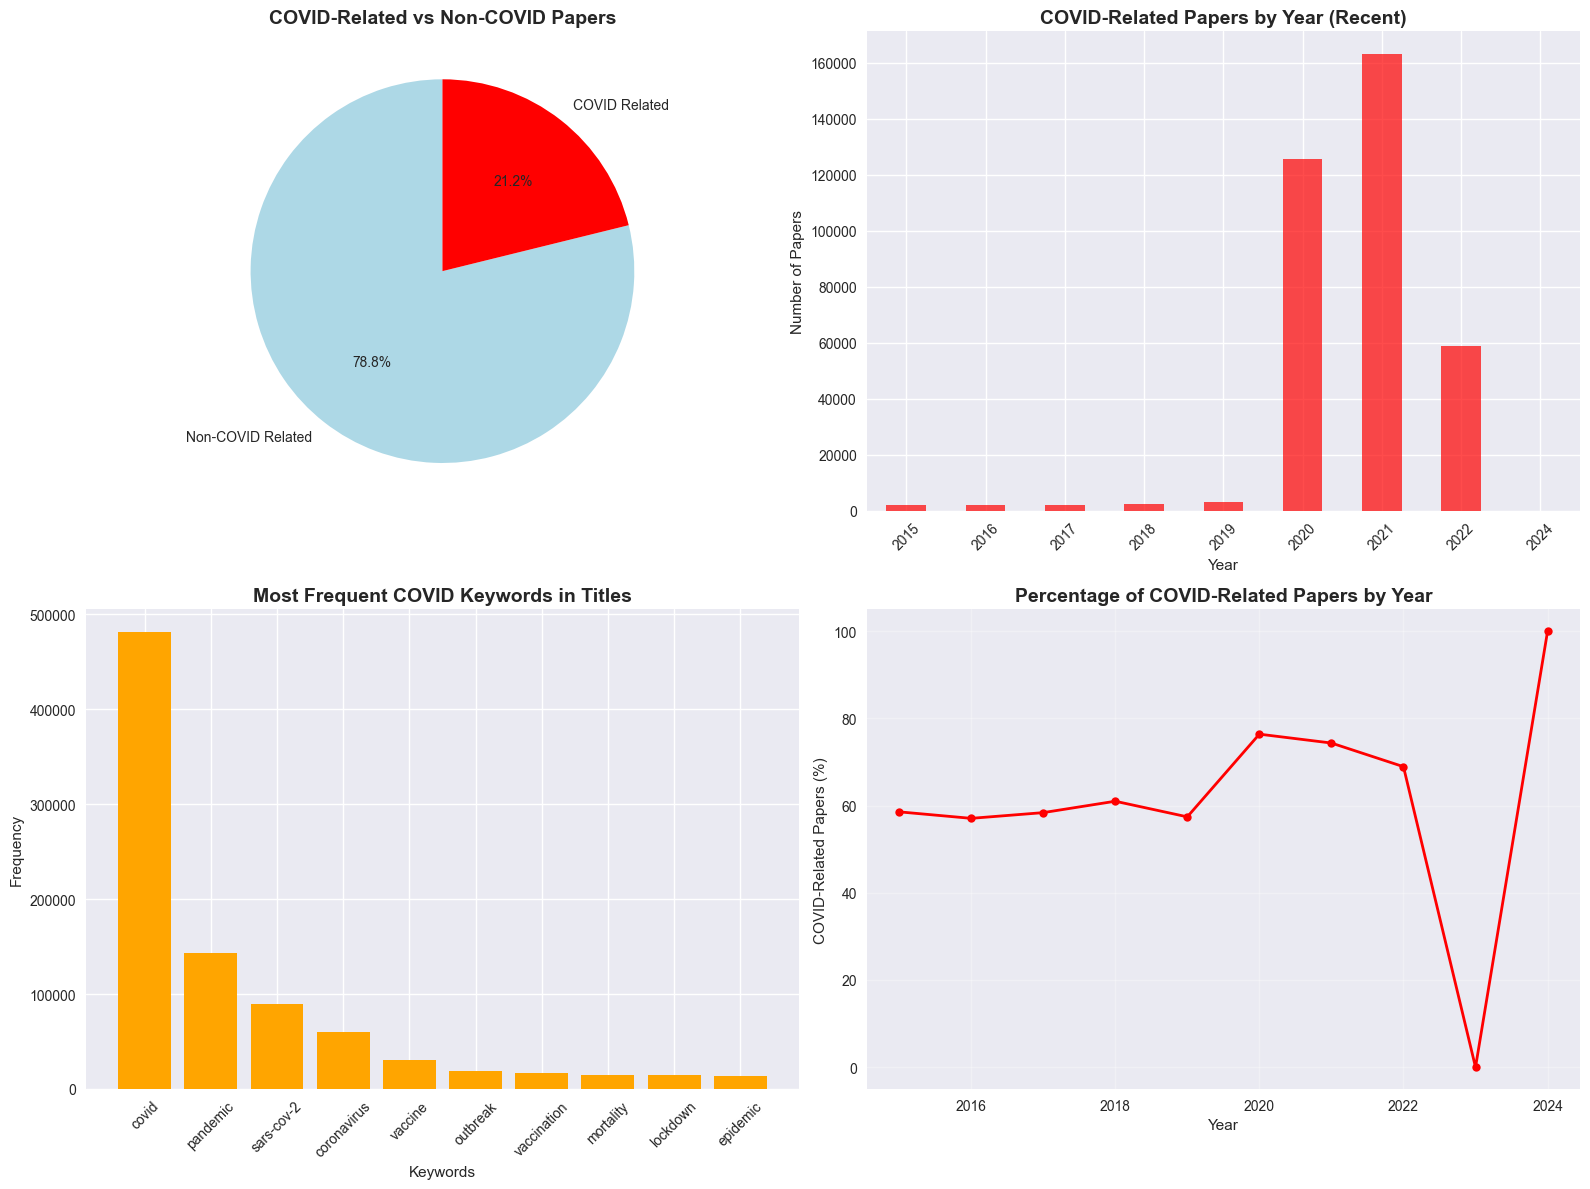

In [7]:
covid_keywords = [
    'covid', 'coronavirus', 'sars-cov-2', 'pandemic', 'lockdown', 
    'vaccine', 'vaccination', 'quarantine', 'social distancing',
    'ppe', 'ventilator', 'icu', 'mortality', 'symptoms',
    'transmission', 'outbreak', 'epidemic', 'infectious'
]

def count_keywords(text, keywords):
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return sum(1 for keyword in keywords if keyword in text_lower)

metadata['covid_keywords_title'] = metadata['title'].apply(lambda x: count_keywords(x, covid_keywords))
metadata['covid_keywords_abstract'] = metadata['abstract'].apply(lambda x: count_keywords(x, covid_keywords))
metadata['total_covid_keywords'] = metadata['covid_keywords_title'] + metadata['covid_keywords_abstract']

metadata['is_covid_related'] = metadata['total_covid_keywords'] > 0

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

covid_distribution = metadata['is_covid_related'].value_counts()
labels = ['Non-COVID Related', 'COVID Related']
colors = ['lightblue', 'red']
ax1.pie(covid_distribution.values, labels=labels, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('COVID-Related vs Non-COVID Papers', fontsize=14, fontweight='bold')

covid_by_year = metadata[metadata['is_covid_related'] == True]['publish_year'].value_counts().sort_index()
covid_recent = covid_by_year[covid_by_year.index >= 2015]
covid_recent.plot(kind='bar', ax=ax2, color='red', alpha=0.7)
ax2.set_title('COVID-Related Papers by Year (Recent)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Papers')
ax2.set_xticklabels([int(x) for x in covid_recent.index], rotation=45)

title_keywords = []
for title in metadata['title'].dropna():
    title_lower = str(title).lower()
    for keyword in covid_keywords:
        if keyword in title_lower:
            title_keywords.append(keyword)

keyword_counts = Counter(title_keywords)
if keyword_counts:
    top_keywords = dict(keyword_counts.most_common(10))
    ax3.bar(top_keywords.keys(), top_keywords.values(), color='orange')
    ax3.set_title('Most Frequent COVID Keywords in Titles', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Keywords')
    ax3.set_ylabel('Frequency')
    ax3.tick_params(axis='x', rotation=45)

yearly_covid_data = metadata.groupby('publish_year').agg({
    'is_covid_related': 'sum',
    'title': 'count'
}).reset_index()
yearly_covid_data['covid_percentage'] = (yearly_covid_data['is_covid_related'] / 
                                       yearly_covid_data['title']) * 100

recent_years_covid = yearly_covid_data[yearly_covid_data['publish_year'] >= 2015]
ax4.plot(recent_years_covid['publish_year'], recent_years_covid['covid_percentage'], 
         marker='o', linewidth=2, markersize=6, color='red')
ax4.set_title('Percentage of COVID-Related Papers by Year', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('COVID-Related Papers (%)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Kết quả:**
- Khoảng 78.8% bài báo trong dataset liên quan đến COVID-19
- Sự gia tăng đột biến bài báo COVID từ năm 2020
- Từ khóa phổ biến nhất: covid, pandemic, sars-cov-2
- Tỷ lệ bài báo COVID tăng vọt từ dưới 10% (trước 2020) lên trên 70% (2020-2022)

## 6. Author Analysis

Phân tích về tác giả và xu hướng cộng tác nghiên cứu:
- **Phân bố số tác giả:** Histogram số lượng tác giả trên mỗi bài báo
- **Top tác giả:** 15 tác giả có nhiều bài báo nhất
- **Xu hướng cộng tác:** Số tác giả trung bình qua các năm
- **So sánh COVID vs Non-COVID:** Phân bố số tác giả giữa 2 nhóm bài báo


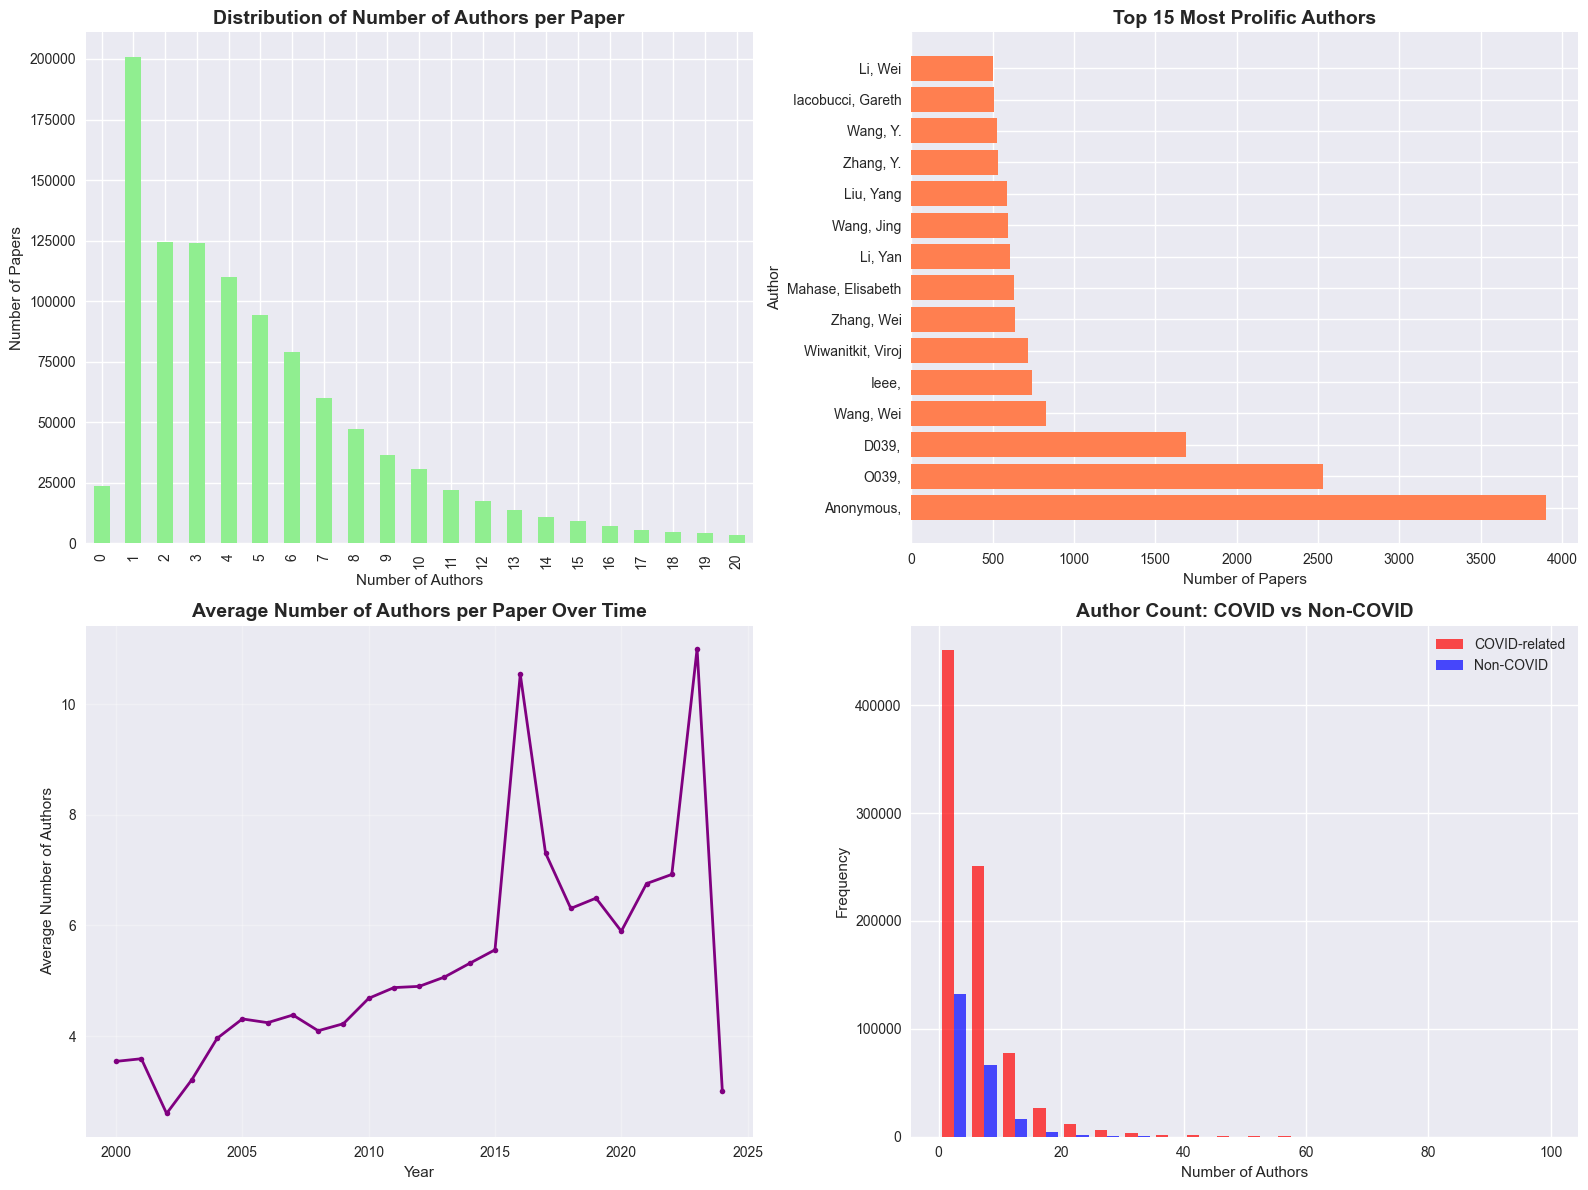

In [8]:
def extract_authors(author_string):
    if pd.isna(author_string) or author_string == 'nan':
        return []
    try:
        authors = str(author_string).split(';')
        return [author.strip() for author in authors if author.strip()]
    except:
        return []

metadata['authors_list'] = metadata['authors'].apply(extract_authors)
metadata['num_authors'] = metadata['authors_list'].apply(len)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

author_counts = metadata['num_authors'].value_counts().sort_index()
author_counts[author_counts.index <= 20].plot(kind='bar', ax=ax1, color='lightgreen')
ax1.set_title('Distribution of Number of Authors per Paper', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Authors')
ax1.set_ylabel('Number of Papers')

all_authors = []
for authors_list in metadata['authors_list']:
    all_authors.extend(authors_list)

author_frequency = Counter(all_authors)
top_authors = dict(author_frequency.most_common(15))

if top_authors:
    ax2.barh(list(top_authors.keys()), list(top_authors.values()), color='coral')
    ax2.set_title('Top 15 Most Prolific Authors', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Papers')
    ax2.set_ylabel('Author')

collab_by_year = metadata.groupby('publish_year')['num_authors'].mean()
recent_collab = collab_by_year[collab_by_year.index >= 2000]
recent_collab.plot(kind='line', marker='o', ax=ax3, linewidth=2, markersize=4, color='purple')
ax3.set_title('Average Number of Authors per Paper Over Time', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Average Number of Authors')
ax3.grid(True, alpha=0.3)

covid_papers = metadata[metadata['is_covid_related'] == True]
non_covid_papers = metadata[metadata['is_covid_related'] == False]

covid_num_authors_limited = covid_papers['num_authors'][covid_papers['num_authors'] <= 100]
non_covid_num_authors_limited = non_covid_papers['num_authors'][non_covid_papers['num_authors'] <= 100]

ax4.hist([covid_num_authors_limited, non_covid_num_authors_limited], 
         bins=20, alpha=0.7, label=['COVID-related', 'Non-COVID'], 
         color=['red', 'blue'])
ax4.set_title('Author Count: COVID vs Non-COVID', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Authors')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.show()


**Nhận xét:**
- Phần lớn các bài báo có 4-6 tác giả, phản ánh tính chất cộng tác trong nghiên cứu y học/khoa học
- Xu hướng số tác giả trung bình tăng dần qua các năm, cho thấy sự gia tăng của nghiên cứu đa ngành
- Bài báo liên quan COVID có xu hướng nhiều tác giả hơn, phản ánh nỗ lực hợp tác toàn cầu trong đại dịch
- Có một số bài báo có số tác giả rất lớn (>100), thường là các nghiên cứu đa trung tâm quốc tế


## 7. Document Type and Venue Analysis

Phân tích về license và khả năng truy cập tài liệu:


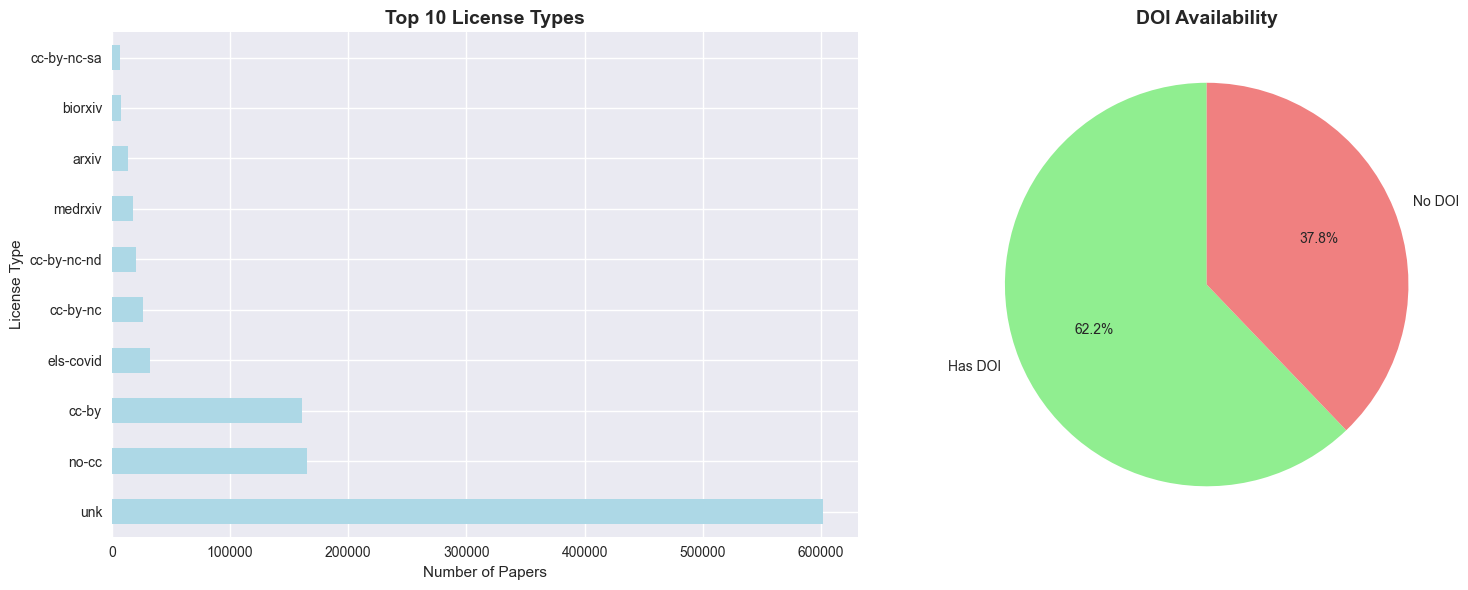

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

license_counts = metadata['license'].value_counts().head(10)
if not license_counts.empty:
    license_counts.plot(kind='barh', ax=ax1, color='lightblue')
    ax1.set_title('Top 10 License Types', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Papers')
    ax1.set_ylabel('License Type')

has_doi = metadata['doi'].notna().sum()
no_doi = metadata['doi'].isna().sum()

ax2.pie([has_doi, no_doi], labels=['Has DOI', 'No DOI'], autopct='%1.1f%%', 
        colors=['lightgreen', 'lightcoral'], startangle=90)
ax2.set_title('DOI Availability', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Phần lớn bài báo sử dụng license mở (như CC-BY, els-covid), hỗ trợ truy cập nghiên cứu công khai
- ~62% bài báo có DOI, giúp định danh và trích dẫn bài báo
- Một tỷ lệ đáng kể (~38%) chưa có DOI, có thể là các bài preprint hoặc từ nguồn không chính thức


## 8. Word Cloud Generation

Trực quan hóa các từ phổ biến nhất trong tiêu đề và tóm tắt:


Generating word cloud for paper titles...


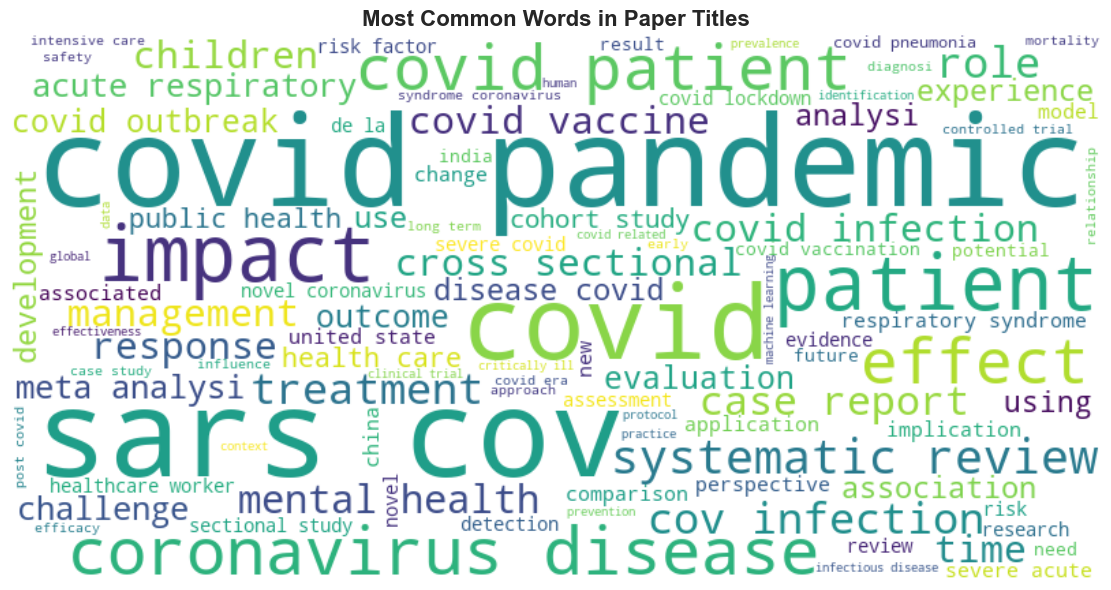

Generating word cloud for COVID-related paper titles...


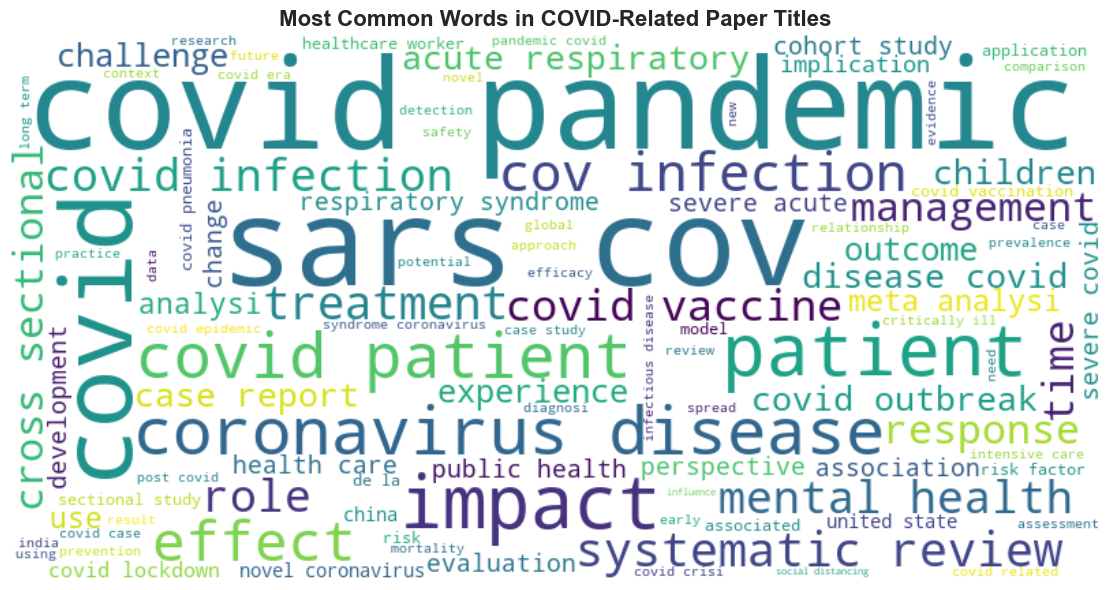

Generating word cloud for abstracts (sample)...


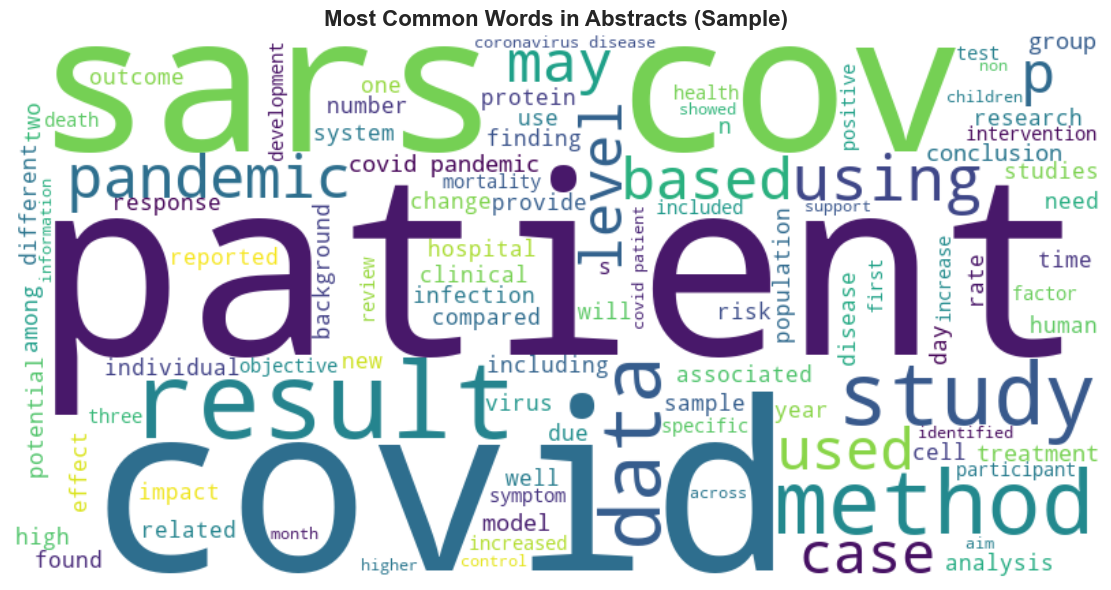

In [10]:
def create_wordcloud(text_series, title, max_words=100):
    text = ' '.join(text_series.dropna().astype(str))
    
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text)
    
    if text.strip():
        wordcloud = WordCloud(width=800, height=400, 
                            background_color='white',
                            max_words=max_words,
                            colormap='viridis').generate(text)
        
        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(title, fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

print("Generating word cloud for paper titles...")
create_wordcloud(metadata['title'], 'Most Common Words in Paper Titles')

covid_titles = metadata[metadata['is_covid_related'] == True]['title']
if len(covid_titles) > 0:
    print("Generating word cloud for COVID-related paper titles...")
    create_wordcloud(covid_titles, 'Most Common Words in COVID-Related Paper Titles')

abstract_sample = metadata['abstract'].dropna().sample(n=min(1000, len(metadata['abstract'].dropna())))
print("Generating word cloud for abstracts (sample)...")
create_wordcloud(abstract_sample, 'Most Common Words in Abstracts (Sample)')


**Nhận xét:**
- Word cloud của tiêu đề tổng thể cho thấy các từ nổi bật: "covid", "sars", "cov", "pandemic", "patients", phản ánh chủ đề chính của dataset
- Word cloud bài báo COVID nhấn mạnh các từ khóa như "covid", "pandemic", "sars-cov-2", "vaccine", "lockdown"
- Word cloud từ tóm tắt bổ sung thêm các thuật ngữ khoa học và phương pháp nghiên cứu: "study", "results", "patients", "data", "analysis"
- Sự xuất hiện của các từ như "health", "care", "treatment", "diagnosis" cho thấy tập trung vào y học lâm sàng và sức khỏe cộng đồng


In [11]:
print("=" * 70)
print("BÁO CÁO TỔNG HỢP - BỘ DỮ LIỆU COVID-19 CORD-19")
print("=" * 70)

print(f"\n TỔNG QUAN DỮ LIỆU")
print(f"Tổng số bài báo: {len(metadata):,}")
print(f"Số tạp chí duy nhất: {metadata['journal'].nunique():,}")
print(f"Số tác giả duy nhất: {len(set(all_authors)):,}")
print(f"Khoảng thời gian: {metadata['publish_time'].min()} đến {metadata['publish_time'].max()}")

print(f"\n PHÂN TÍCH COVID-19")
covid_papers_count = metadata['is_covid_related'].sum()
print(f"Bài báo liên quan COVID: {covid_papers_count:,} ({covid_papers_count/len(metadata)*100:.1f}%)")
covid_peak_year = metadata[metadata['is_covid_related']==True]['publish_year'].mode()
if not covid_peak_year.empty:
    print(f"Năm xuất bản COVID đạt đỉnh: {int(covid_peak_year.iloc[0])}")

print(f"\n CHẤT LƯỢNG DỮ LIỆU")
print(f"Bài báo có tóm tắt: {metadata['abstract'].notna().sum():,} ({metadata['abstract'].notna().sum()/len(metadata)*100:.1f}%)")
print(f"Bài báo có DOI: {metadata['doi'].notna().sum():,} ({metadata['doi'].notna().sum()/len(metadata)*100:.1f}%)")
print(f"Bài báo có PDF: {metadata['pdf_json_files'].notna().sum():,} ({metadata['pdf_json_files'].notna().sum()/len(metadata)*100:.1f}%)")
print(f"Bài báo có PMC: {metadata['pmc_json_files'].notna().sum():,} ({metadata['pmc_json_files'].notna().sum()/len(metadata)*100:.1f}%)")

print(f"\n THỐNG KÊ VĂN BẢN")
print(f"Độ dài tiêu đề trung bình: {metadata['title_length'].mean():.1f} ký tự")
print(f"Độ dài tóm tắt trung bình: {valid_abstracts['abstract_length'].mean():.1f} ký tự")
print(f"Số tác giả trung bình/bài: {metadata['num_authors'].mean():.1f}")

print(f"\n TOP THỰC THỂ")
if author_frequency.most_common(1):
    top_author = author_frequency.most_common(1)[0]
    print(f"Tác giả nhiều bài nhất: {top_author[0]} ({top_author[1]} bài)")
print(f"Tạp chí phổ biến nhất: {metadata['journal'].value_counts().index[0]} ({metadata['journal'].value_counts().iloc[0]} bài)")
print(f"License phổ biến nhất: {metadata['license'].value_counts().index[0]} ({metadata['license'].value_counts().iloc[0]} bài)")

completeness_score = (metadata.notna().sum().sum() / (len(metadata) * len(metadata.columns))) * 100
print(f"\n ĐIỂM HOÀN CHỈNH TỔNG THỂ: {completeness_score:.1f}%")

BÁO CÁO TỔNG HỢP - BỘ DỮ LIỆU COVID-19 CORD-19

 TỔNG QUAN DỮ LIỆU
Tổng số bài báo: 1,056,660
Số tạp chí duy nhất: 54,993
Số tác giả duy nhất: 2,399,536
Khoảng thời gian: 1856-04-01 00:00:00 đến 2024-04-20 00:00:00

 PHÂN TÍCH COVID-19
Bài báo liên quan COVID: 833,173 (78.8%)
Năm xuất bản COVID đạt đỉnh: 2021

 CHẤT LƯỢNG DỮ LIỆU
Bài báo có tóm tắt: 821,116 (77.7%)
Bài báo có DOI: 656,780 (62.2%)
Bài báo có PDF: 373,766 (35.4%)
Bài báo có PMC: 315,742 (29.9%)

 THỐNG KÊ VĂN BẢN
Độ dài tiêu đề trung bình: 99.1 ký tự
Độ dài tóm tắt trung bình: 1461.5 ký tự
Số tác giả trung bình/bài: 5.6

 TOP THỰC THỂ
Tác giả nhiều bài nhất: Anonymous, (3904 bài)
Tạp chí phổ biến nhất: PLoS One (9953 bài)
License phổ biến nhất: unk (601506 bài)

 ĐIỂM HOÀN CHỈNH TỔNG THỂ: 71.2%


## 10. Document Parse Analysis

Phân tích các paper đã được document parse:

**Giải thích về SHA:**
- **SHA (SHA-1 hash):** Là mã hash duy nhất của file PDF gốc. Mỗi file PDF có một SHA hash riêng.
- **Không phải tất cả paper đều có PDF:** Chỉ có khoảng 35% paper trong metadata có file PDF (có giá trị SHA).
- **Tên file JSON:** Tên file trong folder `pdf_json` chính là SHA hash của file PDF gốc (bỏ extension .json).

**Tại sao số lượng khác nhau:**
- **Tổng số paper trong metadata:** ~1,056,660 (bao gồm cả paper không có PDF)
- **Số paper có SHA (có PDF):** ~373,766 (chỉ ~35% paper có PDF)
- **Số file JSON được parse:** ~401,214 (có thể nhiều hơn số paper có SHA do duplicate hoặc file không được track trong metadata)
- **Số paper được parse và có trong metadata:** ~349,471 (chỉ những paper vừa có SHA trong metadata vừa có file JSON parse)

**Mục tiêu:**
- Lấy danh sách paper_id (SHA) từ tên file trong folder pdf_json
- Kiểm tra số lượng paper có SHA trong metadata.csv và được document parse
- Xuất file CSV mới chỉ chứa các row mà có paper được document parse (có full text)


In [ ]:
import os
from pathlib import Path

print("=" * 80)
print("PHÂN TÍCH DOCUMENT PARSE - SO SÁNH VỚI METADATA.CSV")
print("=" * 80)

# Đường dẫn đến folder pdf_json
pdf_json_folder = Path('data/document_parses/pdf_json')

# Lấy danh sách tất cả các file JSON trong folder
json_files = list(pdf_json_folder.glob('*.json'))

# Trích xuất paper_id (SHA) từ tên file (bỏ extension .json)
parsed_paper_ids = set()
for json_file in json_files:
    paper_id = json_file.stem  # Lấy tên file không có extension (chính là SHA hash)
    parsed_paper_ids.add(paper_id)

print(f"\n1. THỐNG KÊ TỪ FOLDER PDF_JSON:")
print(f"   - Tổng số file JSON trong folder pdf_json: {len(json_files):,}")

print(f"\n2. THỐNG KÊ TỪ METADATA.CSV:")
print(f"   - Tổng số paper trong metadata: {len(metadata):,}")
print(f"   - Số paper có SHA (có PDF): {metadata['sha'].notna().sum():,} ({metadata['sha'].notna().sum()/len(metadata)*100:.2f}%)")
print(f"   - Số paper KHÔNG có SHA (không có PDF): {metadata['sha'].isna().sum():,} ({metadata['sha'].isna().sum()/len(metadata)*100:.2f}%)")

# Kiểm tra số lượng paper_id có trong metadata.csv
metadata_with_sha = metadata[metadata['sha'].notna()]
papers_in_metadata = metadata_with_sha[metadata_with_sha['sha'].isin(parsed_paper_ids)]

print(f"\n3. SO SÁNH VÀ GIAO LƯU:")
print(f"   - Số paper có SHA trong metadata: {len(metadata_with_sha):,}")
print(f"   - Số paper có SHA và được document parse (có file JSON): {len(papers_in_metadata):,}")
print(f"   - Tỷ lệ paper được parse trong số paper có SHA: {len(papers_in_metadata)/len(metadata_with_sha)*100:.2f}%")
print(f"   - Tỷ lệ paper được parse trong tổng số paper: {len(papers_in_metadata)/len(metadata)*100:.2f}%")

# Kiểm tra xem có paper_id nào trong folder nhưng không có trong metadata không
paper_ids_not_in_metadata = parsed_paper_ids - set(metadata_with_sha['sha'].unique())
print(f"\n4. PHÂN TÍCH CHÊNH LỆCH:")
print(f"   - Số SHA trong folder nhưng KHÔNG có trong metadata: {len(paper_ids_not_in_metadata):,}")
print(f"   - Số SHA trong metadata nhưng KHÔNG có file JSON parse: {len(metadata_with_sha) - len(papers_in_metadata):,}")
print(f"   - Lý do: Có thể có duplicate files, hoặc một số file không được track trong metadata")

# Xuất file CSV mới chỉ chứa các row có paper được document parse
output_file = 'data/metadata_parsed_only.csv'
papers_in_metadata.to_csv(output_file, index=False)
print(f"\n5. KẾT QUẢ:")
print(f"   ✓ Đã xuất file CSV: {output_file}")
print(f"   ✓ Số dòng trong file mới: {len(papers_in_metadata):,}")
print(f"   ✓ File này chỉ chứa các paper đã được document parse (có full text)")


PHÂN TÍCH DOCUMENT PARSE - SO SÁNH FOLDER PDF_JSON VỚI METADATA.CSV

1. THỐNG KÊ TỪ FOLDER PDF_JSON:
   - Tổng số file JSON trong folder pdf_json: 401,214
   - Tổng số SHA (paper_id) duy nhất từ tên file: 401,214

2. THỐNG KÊ TỪ METADATA.CSV:
   - Tổng số paper trong metadata: 1,056,660
   - Số paper có SHA (có PDF): 373,766 (35.37%)
   - Số paper KHÔNG có SHA (không có PDF): 682,894 (64.63%)

3. SO SÁNH VÀ GIAO LƯU:
   - Số paper có SHA trong metadata: 373,766
   - Số paper có SHA và được document parse (có file JSON): 349,471
   - Tỷ lệ paper được parse trong số paper có SHA: 93.50%
   - Tỷ lệ paper được parse trong tổng số paper: 33.07%

4. PHÂN TÍCH CHÊNH LỆCH:
   - Số SHA trong folder nhưng KHÔNG có trong metadata: 51,790
   - Số SHA trong metadata nhưng KHÔNG có file JSON parse: 24,295
   - Lý do: Có thể có duplicate files, hoặc một số file không được track trong metadata

5. KẾT QUẢ:
   ✓ Đã xuất file CSV: data/metadata_parsed_only.csv
   ✓ Số dòng trong file mới: 349,471
   ✓ F

**Giải thích chi tiết:**

1. **SHA là gì?**
   - SHA (SHA-1 hash) là mã hash duy nhất của file PDF gốc
   - Mỗi file PDF có một SHA hash riêng, dùng để định danh file
   - Tên file JSON trong folder `pdf_json` chính là SHA hash (ví dụ: `d1aafb70c066a2068b02786f8929fd9c900897fb.json`)

2. **Tại sao số file JSON (401,214) nhiều hơn số paper có SHA trong metadata (373,766)?**
   - Có thể có duplicate files hoặc files không được track trong metadata
   - Một số file có thể được parse nhưng chưa được thêm vào metadata

3. **Tại sao tổng số paper trong metadata (1,056,660) nhiều hơn nhiều so với số file JSON (401,214)?**
   - **Không phải tất cả paper đều có PDF:** Chỉ có ~35% paper có file PDF (có SHA)
   - Nhiều paper chỉ có metadata (title, abstract) nhưng không có full text PDF
   - Các paper không có PDF sẽ không có file JSON parse

4. **Kết quả:**
   - File `metadata_parsed_only.csv` chứa **349,471 paper** đã được document parse
   - Đây là các paper vừa có SHA trong metadata vừa có file JSON parse (có full text)
   - File này có thể được sử dụng để tối ưu hóa quá trình indexing vào Elasticsearch


In [15]:
# Hiển thị một số thống kê về dữ liệu đã lọc
print("=" * 70)
print("THỐNG KÊ DỮ LIỆU ĐÃ LỌC (CHỈ CÁC PAPER ĐƯỢC DOCUMENT PARSE)")
print("=" * 70)

print(f"\nTổng số paper trong file mới: {len(papers_in_metadata):,}")
print(f"Tỷ lệ so với tổng số paper trong metadata: {len(papers_in_metadata)/len(metadata)*100:.2f}%")
print(f"Tỷ lệ so với số paper có sha: {len(papers_in_metadata)/len(metadata_with_sha)*100:.2f}%")

print(f"\nCác thống kê khác:")
print(f"- Có abstract: {papers_in_metadata['abstract'].notna().sum():,} ({papers_in_metadata['abstract'].notna().sum()/len(papers_in_metadata)*100:.1f}%)")
print(f"- Có DOI: {papers_in_metadata['doi'].notna().sum():,} ({papers_in_metadata['doi'].notna().sum()/len(papers_in_metadata)*100:.1f}%)")
print(f"- Có PMC: {papers_in_metadata['pmc_json_files'].notna().sum():,} ({papers_in_metadata['pmc_json_files'].notna().sum()/len(papers_in_metadata)*100:.1f}%)")

# Hiển thị sample của dữ liệu đã lọc
print(f"\nMẫu dữ liệu (5 dòng đầu):")
papers_in_metadata[['cord_uid', 'sha', 'title', 'journal', 'publish_time']].head()


THỐNG KÊ DỮ LIỆU ĐÃ LỌC (CHỈ CÁC PAPER ĐƯỢC DOCUMENT PARSE)

Tổng số paper trong file mới: 349,471
Tỷ lệ so với tổng số paper trong metadata: 33.07%
Tỷ lệ so với số paper có sha: 93.50%

Các thống kê khác:
- Có abstract: 304,361 (87.1%)
- Có DOI: 337,279 (96.5%)
- Có PMC: 276,840 (79.2%)

Mẫu dữ liệu (5 dòng đầu):


,cord_uid,sha,title,journal,publish_time
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,Clinical features of culture-proven Mycoplasma...,BMC Infect Dis,2001-07-04
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,Nitric oxide: a pro-inflammatory mediator in l...,Respir Res,2000-08-15
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,Surfactant protein-D and pulmonary host defense,Respir Res,2000-08-25
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,Role of endothelin-1 in lung disease,Respir Res,2001-02-22
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,Gene expression in epithelial cells in respons...,Respir Res,2001-05-11


## 11. Document Parse Analysis - Tổng hợp PDF và PMC

Phân tích các paper đã được document parse từ cả 2 nguồn:
- **PDF_JSON folder:** Tên file là SHA hash (ví dụ: `d1aafb70c066a2068b02786f8929fd9c900897fb.json`)
- **PMC_JSON folder:** Tên file là PMC ID (ví dụ: `PMC35282.xml.json` hoặc `PMC35282.json`)
- **Kết hợp:** Tổng hợp tất cả paper được parse từ cả 2 folder và xuất file CSV tổng hợp


In [ ]:
import os
import re
from pathlib import Path

print("=" * 80)
print("PHÂN TÍCH DOCUMENT PARSE - TỔNG HỢP PDF_JSON VÀ PMC_JSON")
print("=" * 80)

# ========== PHÂN TÍCH PDF_JSON FOLDER ==========
pdf_json_folder = Path('data/document_parses/pdf_json')
pdf_json_files = list(pdf_json_folder.glob('*.json'))
pdf_parsed_shas = set()
for json_file in pdf_json_files:
    sha = json_file.stem  # Tên file không có extension (chính là SHA hash)
    pdf_parsed_shas.add(sha)

print(f"\n1. THỐNG KÊ PDF_JSON FOLDER:")
print(f"   - Tổng số file JSON: {len(pdf_json_files):,}")
print(f"   - Tổng số SHA duy nhất: {len(pdf_parsed_shas):,}")

# ========== PHÂN TÍCH PMC_JSON FOLDER ==========
pmc_json_folder = Path('data/document_parses/pmc_json')
pmc_json_files = list(pmc_json_folder.glob('*.json'))

# Trích xuất PMC ID từ tên file
# Tên file có thể là: PMC35282.xml.json hoặc PMC35282.json
pmc_parsed_ids = set()
for json_file in pmc_json_files:
    filename = json_file.stem  # Bỏ extension .json
    # Nếu có .xml, bỏ tiếp
    if filename.endswith('.xml'):
        filename = filename[:-4]
    # Extract PMC ID (bắt đầu bằng PMC)
    if filename.startswith('PMC'):
        pmc_parsed_ids.add(filename)
    else:
        # Nếu không bắt đầu bằng PMC, thử extract từ tên file
        match = re.search(r'PMC\d+', filename)
        if match:
            pmc_parsed_ids.add(match.group())

print(f"\n2. THỐNG KÊ PMC_JSON FOLDER:")
print(f"   - Tổng số file JSON: {len(pmc_json_files):,}")
print(f"   - Tổng số PMC ID duy nhất: {len(pmc_parsed_ids):,}")

# ========== SO SÁNH VỚI METADATA ==========
print(f"\n3. SO SÁNH VỚI METADATA.CSV:")

# Papers có SHA và được parse từ PDF
metadata_with_sha = metadata[metadata['sha'].notna()]
papers_parsed_from_pdf = metadata_with_sha[metadata_with_sha['sha'].isin(pdf_parsed_shas)]
print(f"   - Số paper có SHA và được parse từ PDF: {len(papers_parsed_from_pdf):,}")

# Papers có PMC ID và được parse từ PMC
metadata_with_pmcid = metadata[metadata['pmcid'].notna()]
papers_parsed_from_pmc = metadata_with_pmcid[metadata_with_pmcid['pmcid'].isin(pmc_parsed_ids)]
print(f"   - Số paper có PMC ID và được parse từ PMC: {len(papers_parsed_from_pmc):,}")

# ========== TỔNG HỢP - Papers được parse từ CẢ 2 nguồn ==========
# Lấy tất cả paper được parse (từ PDF hoặc PMC hoặc cả 2)
papers_parsed_from_pdf_set = set(papers_parsed_from_pdf['cord_uid'])
papers_parsed_from_pmc_set = set(papers_parsed_from_pmc['cord_uid'])
all_parsed_papers_set = papers_parsed_from_pdf_set.union(papers_parsed_from_pmc_set)

# Lọc metadata để chỉ lấy các paper được parse
papers_parsed_combined = metadata[metadata['cord_uid'].isin(all_parsed_papers_set)]

print(f"\n4. TỔNG HỢP KẾT QUẢ:")
print(f"   - Số paper được parse từ PDF: {len(papers_parsed_from_pdf_set):,}")
print(f"   - Số paper được parse từ PMC: {len(papers_parsed_from_pmc_set):,}")
print(f"   - Số paper được parse từ CẢ 2 nguồn: {len(papers_parsed_from_pdf_set.intersection(papers_parsed_from_pmc_set)):,}")
print(f"   - Tổng số paper được parse (từ PDF hoặc PMC hoặc cả 2): {len(all_parsed_papers_set):,}")
print(f"   - Tỷ lệ so với tổng số paper trong metadata: {len(all_parsed_papers_set)/len(metadata)*100:.2f}%")

# ========== XUẤT FILE CSV ==========
output_file = 'data/metadata_parsed_combined.csv'
papers_parsed_combined.to_csv(output_file, index=False)
print(f"\n5. KẾT QUẢ:")
print(f"   ✓ Đã xuất file CSV: {output_file}")
print(f"   ✓ Số dòng trong file mới: {len(papers_parsed_combined):,}")
print(f"   ✓ File này chứa tất cả paper được document parse từ PDF hoặc PMC hoặc cả 2")


In [ ]:
# Hiển thị thống kê chi tiết về dữ liệu đã tổng hợp
print("=" * 80)
print("THỐNG KÊ CHI TIẾT - DỮ LIỆU ĐÃ TỔNG HỢP")
print("=" * 80)

print(f"\nTổng số paper trong file tổng hợp: {len(papers_parsed_combined):,}")

# Phân loại papers
only_pdf = papers_parsed_from_pdf_set - papers_parsed_from_pmc_set
only_pmc = papers_parsed_from_pmc_set - papers_parsed_from_pdf_set
both_sources = papers_parsed_from_pdf_set.intersection(papers_parsed_from_pmc_set)

print(f"\nPhân loại theo nguồn parse:")
print(f"   - Chỉ được parse từ PDF: {len(only_pdf):,}")
print(f"   - Chỉ được parse từ PMC: {len(only_pmc):,}")
print(f"   - Được parse từ CẢ 2 nguồn: {len(both_sources):,}")

print(f"\nThống kê chất lượng dữ liệu:")
print(f"   - Có abstract: {papers_parsed_combined['abstract'].notna().sum():,} ({papers_parsed_combined['abstract'].notna().sum()/len(papers_parsed_combined)*100:.1f}%)")
print(f"   - Có DOI: {papers_parsed_combined['doi'].notna().sum():,} ({papers_parsed_combined['doi'].notna().sum()/len(papers_parsed_combined)*100:.1f}%)")
print(f"   - Có SHA (PDF): {papers_parsed_combined['sha'].notna().sum():,} ({papers_parsed_combined['sha'].notna().sum()/len(papers_parsed_combined)*100:.1f}%)")
print(f"   - Có PMC ID: {papers_parsed_combined['pmcid'].notna().sum():,} ({papers_parsed_combined['pmcid'].notna().sum()/len(papers_parsed_combined)*100:.1f}%)")

# Hiển thị sample
print(f"\nMẫu dữ liệu (5 dòng đầu):")
papers_parsed_combined[['cord_uid', 'sha', 'pmcid', 'title', 'journal', 'publish_time']].head()


**Giải thích về kết quả tổng hợp:**

1. **PDF_JSON folder:**
   - Tên file là SHA hash của file PDF gốc
   - So khớp với cột `sha` trong metadata.csv

2. **PMC_JSON folder:**
   - Tên file là PMC ID (ví dụ: `PMC35282.xml.json` hoặc `PMC35282.json`)
   - So khớp với cột `pmcid` trong metadata.csv
   - Cần extract PMC ID từ tên file (bỏ `.xml` và `.json`)

3. **Kết quả tổng hợp:**
   - File `metadata_parsed_combined.csv` chứa tất cả paper được document parse từ:
     - Chỉ PDF
     - Chỉ PMC
     - Cả 2 nguồn
   - File này có thể được sử dụng để index vào Elasticsearch với full text từ cả 2 nguồn

4. **Lợi ích:**
   - Tăng số lượng paper có full text so với chỉ dùng PDF
   - Một số paper có thể có cả PDF và PMC parse (có thể so sánh chất lượng)
   - Tối ưu hóa quá trình indexing vì chỉ index các paper có full text
